### I am creating a new notebook in which i am trying to implement whatever I know about logistic regression using a project named heart disease prediction using a dataset from kaggle.

In [90]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier

### Loading the dataset

In [91]:
df = pd.read_csv("./Datasets/disease_prediction.csv")
df.head


<bound method NDFrame.head of      patient_id  age  gender  glucose_mg_dl  cholesterol_mg_dl  systolic_bp  \
0             1   32    Male            101                235          152   
1             2   31    Male            124                191          134   
2             3   45    Male             57                141          114   
3             4   75  Female             69                268          120   
4             5   53    Male            107                163          131   
..          ...  ...     ...            ...                ...          ...   
995         996   24    Male            105                237           86   
996         997   40    Male            120                219          133   
997         998   44  Female            114                273          114   
998         999   31    Male             95                231          130   
999        1000   83    Male            109                256          103   

     diastolic_bp   b

### Display Basic Information

In [92]:
#First records
df.head(10)

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,2,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,3,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,4,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,5,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes
5,6,66,Male,151,209,105,90,23.0,63,No,No,Low,No,Yes
6,7,76,Male,56,156,128,89,27.0,77,No,Yes,High,No,No
7,8,64,Male,97,150,112,77,25.4,86,Yes,Yes,Medium,Yes,Yes
8,9,28,Male,60,222,118,75,27.7,82,Yes,No,Medium,No,No
9,10,64,Male,128,176,119,85,31.2,85,No,No,High,Yes,Yes


In [93]:
#Last records
df.tail(10)

,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
990,991,29,Female,124,210,97,86,19.4,84,No,No,Low,Yes,No
991,992,36,Female,134,143,98,83,23.0,76,No,No,Low,Yes,Yes
992,993,22,Male,125,231,140,80,22.4,82,No,Yes,Medium,No,No
993,994,71,Male,156,177,162,82,23.8,62,Yes,Yes,High,Yes,Yes
994,995,30,Female,108,244,147,85,32.8,70,Yes,No,Medium,Yes,Yes
995,996,24,Male,105,237,86,86,30.9,69,Yes,Yes,Medium,No,No
996,997,40,Male,120,219,133,72,34.3,92,Yes,Yes,Medium,No,No
997,998,44,Female,114,273,114,74,36.0,76,No,No,Low,No,Yes
998,999,31,Male,95,231,130,72,28.2,81,Yes,Yes,Medium,Yes,No
999,1000,83,Male,109,256,103,86,30.3,64,Yes,Yes,High,No,Yes


In [94]:
df.describe()

,patient_id,age,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,51.190000,104.163000,210.014000,123.893000,81.032000,26.093000,75.968000
std,288.819436,19.847514,25.076508,39.749111,18.701211,9.969974,4.758282,9.902982
min,1.000000,18.000000,30.000000,89.000000,67.000000,49.000000,16.000000,47.000000
25%,250.750000,33.000000,87.000000,183.000000,111.000000,74.000000,22.900000,70.000000
50%,500.500000,52.500000,105.000000,210.500000,124.000000,81.000000,26.000000,76.000000
75%,750.250000,69.000000,121.000000,235.250000,135.000000,88.000000,29.300000,83.000000
max,1000.000000,85.000000,184.000000,339.000000,195.000000,113.000000,41.500000,114.000000


In [95]:
#dataset dimensions (rows and columns).
df.shape

(1000, 14)

In [96]:
#List all column names.
df.columns

Index(['patient_id', 'age', 'gender', 'glucose_mg_dl', 'cholesterol_mg_dl',
       'systolic_bp', 'diastolic_bp', 'bmi', 'heart_rate', 'smoking',
       'alcohol_consumption', 'physical_activity', 'family_history',
       'disease'],
      dtype='object')

In [97]:
#BAsic info from the dataset
print('==== Dataset Overview ====')
print(f'Total patients: {len(df)}')
print(f'Total Columns: {len(df.columns)}')
print(f'\n Column Names: {list(df.columns)}')

print('\n=== Data Types ===')
print(df.dtypes)

print('\n=== ANY MISSING VALUES? ===')
missing = df.isnull().sum()
if missing.sum() == 0:
    print("Great News! No missing values found.")
else:
    print(missing[missing > 0])
    

==== Dataset Overview ====
Total patients: 1000
Total Columns: 14

 Column Names: ['patient_id', 'age', 'gender', 'glucose_mg_dl', 'cholesterol_mg_dl', 'systolic_bp', 'diastolic_bp', 'bmi', 'heart_rate', 'smoking', 'alcohol_consumption', 'physical_activity', 'family_history', 'disease']

=== Data Types ===
patient_id               int64
age                      int64
gender                  object
glucose_mg_dl            int64
cholesterol_mg_dl        int64
systolic_bp              int64
diastolic_bp             int64
bmi                    float64
heart_rate               int64
smoking                 object
alcohol_consumption     object
physical_activity       object
family_history          object
disease                 object
dtype: object

=== ANY MISSING VALUES? ===
Great News! No missing values found.


In [98]:
## Check for duplicate values
df.duplicated().sum()


0

In [99]:
#Summary
df.describe()

,patient_id,age,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,51.190000,104.163000,210.014000,123.893000,81.032000,26.093000,75.968000
std,288.819436,19.847514,25.076508,39.749111,18.701211,9.969974,4.758282,9.902982
min,1.000000,18.000000,30.000000,89.000000,67.000000,49.000000,16.000000,47.000000
25%,250.750000,33.000000,87.000000,183.000000,111.000000,74.000000,22.900000,70.000000
50%,500.500000,52.500000,105.000000,210.500000,124.000000,81.000000,26.000000,76.000000
75%,750.250000,69.000000,121.000000,235.250000,135.000000,88.000000,29.300000,83.000000
max,1000.000000,85.000000,184.000000,339.000000,195.000000,113.000000,41.500000,114.000000


## EDA


In [100]:
def show_fig():
    plt.tight_layout()
    plt.show()

plot_no = 1

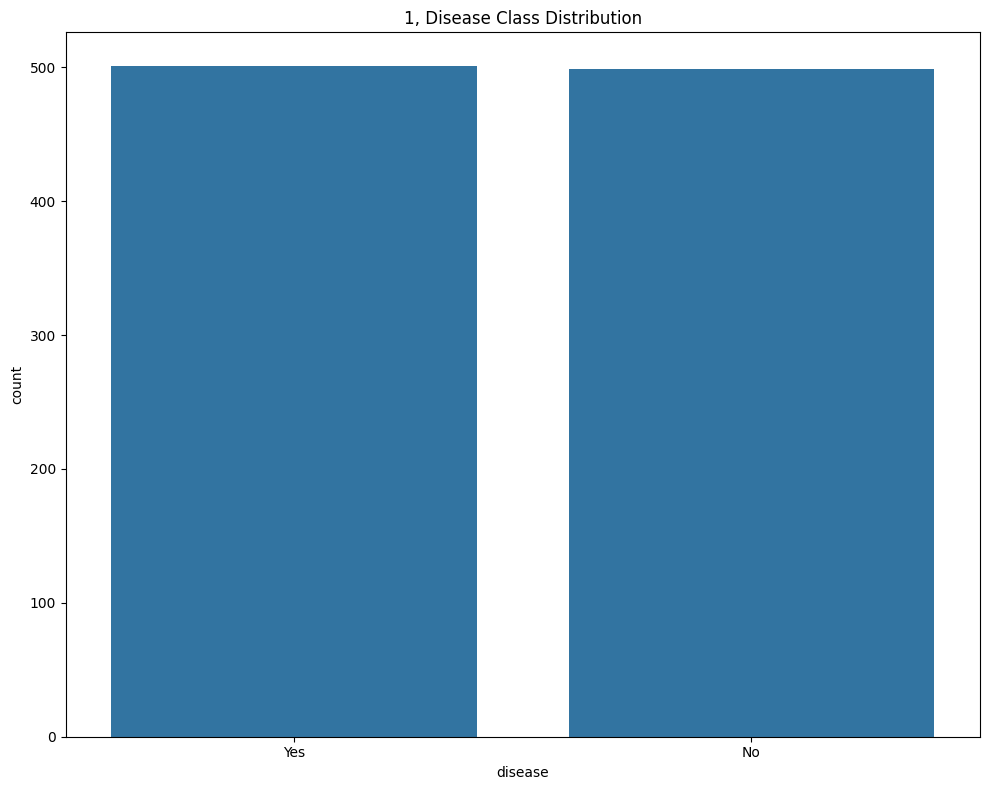

In [101]:
fig = plt.figure(figsize=(10,8))
sns.countplot(data=df, x='disease')
plt.title(f'{plot_no}, Disease Class Distribution')
show_fig()
plot_no += 1

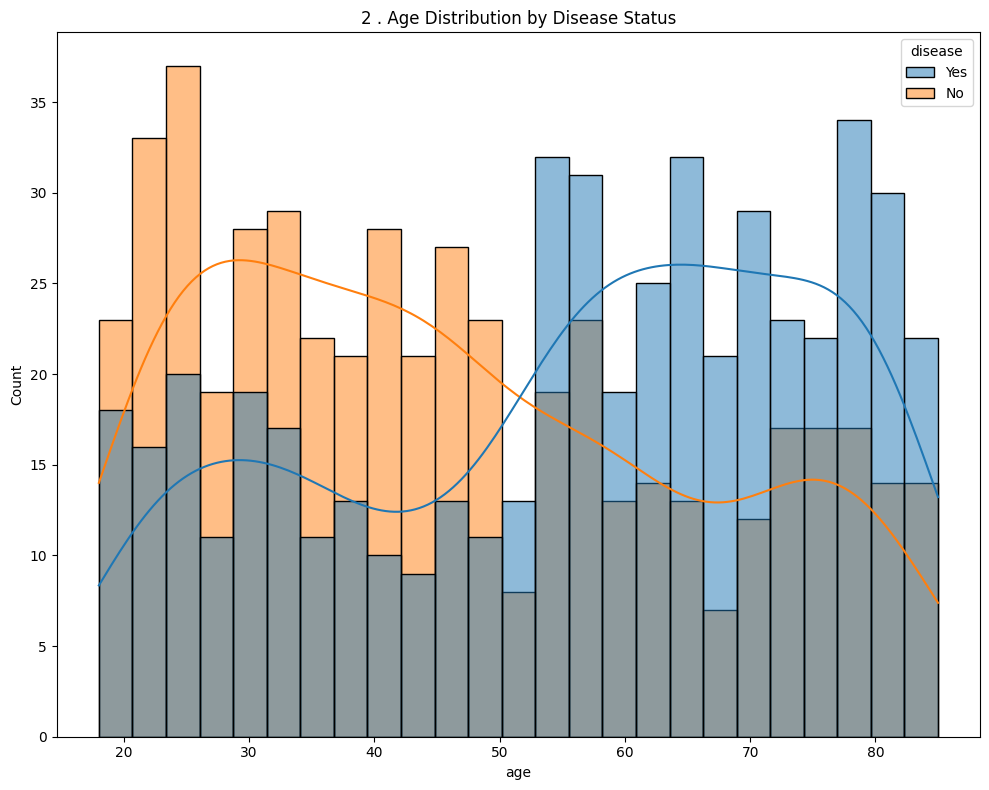

In [102]:
fig = plt.figure(figsize=(10,8))
sns.histplot(data=df, x='age', hue='disease', kde=True, bins=25)
plt.title(f'{plot_no} . Age Distribution by Disease Status')
show_fig()
plot_no += 1

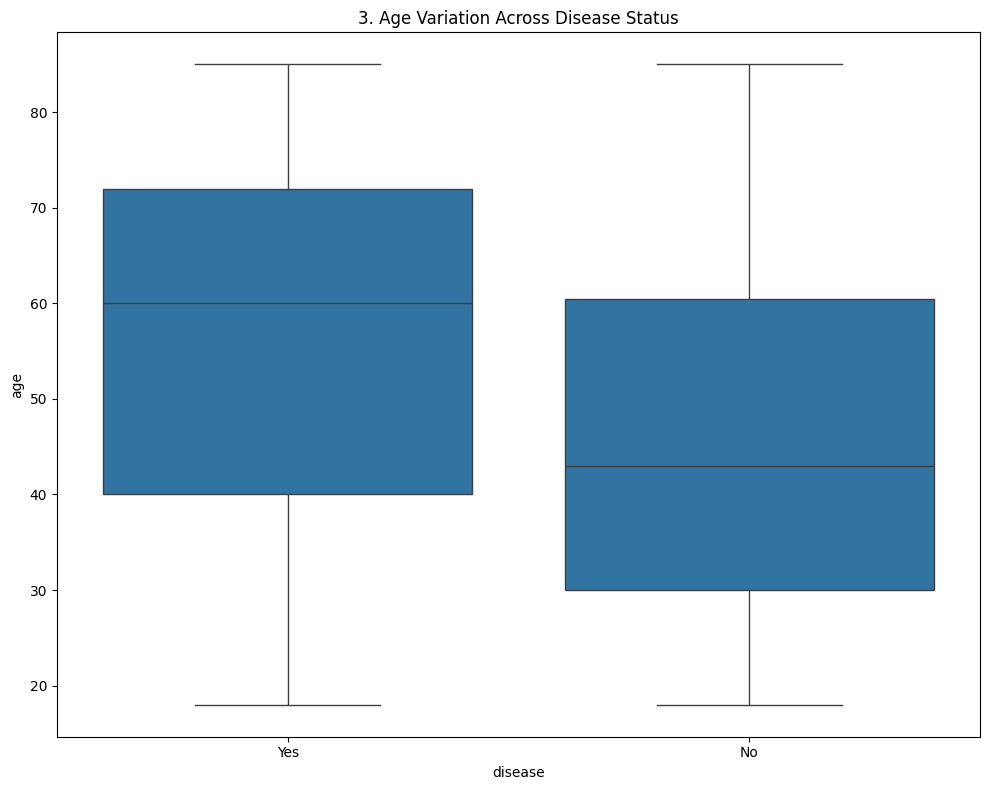

In [103]:
fig = plt.figure(figsize=(10,8))
sns.boxplot(data=df, x='disease', y='age')
plt.title(f'{plot_no}. Age Variation Across Disease Status')
show_fig()
plot_no += 1

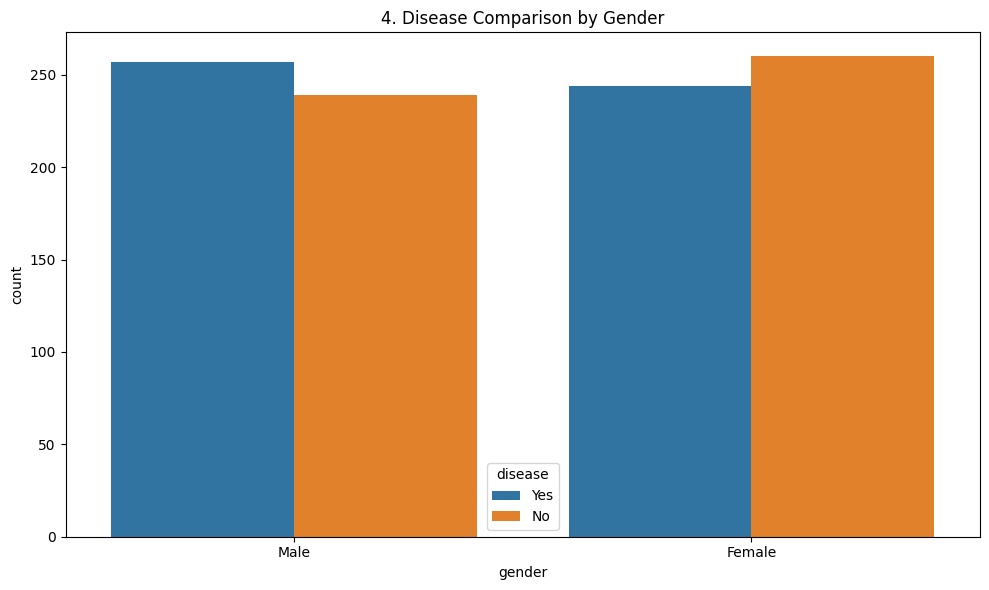

In [104]:
fig = plt.figure(figsize=(10,6))
sns.countplot(data=df, x='gender', hue='disease')
plt.title(f'{plot_no}. Disease Comparison by Gender')
show_fig()
plot_no += 1

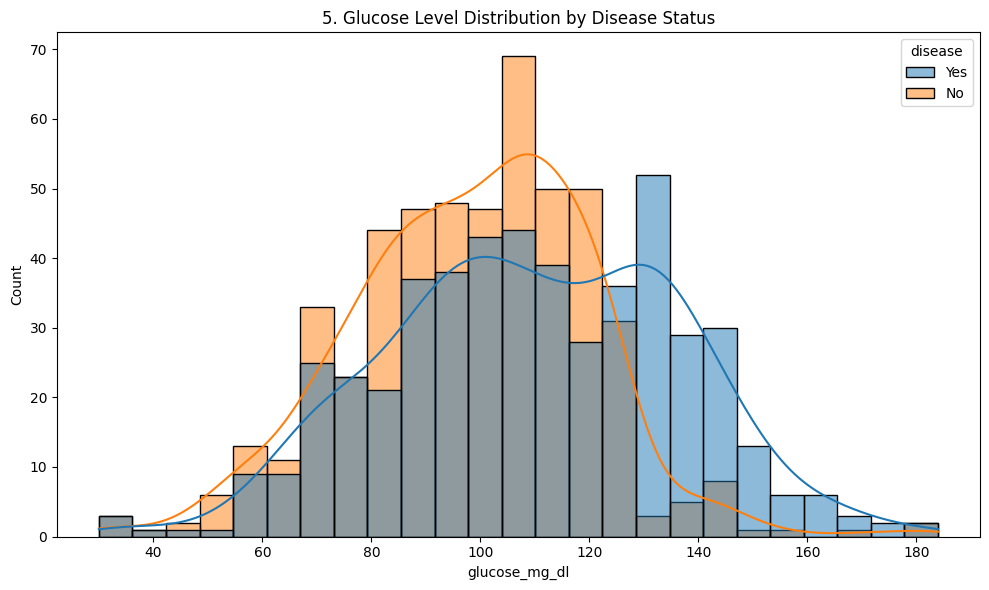

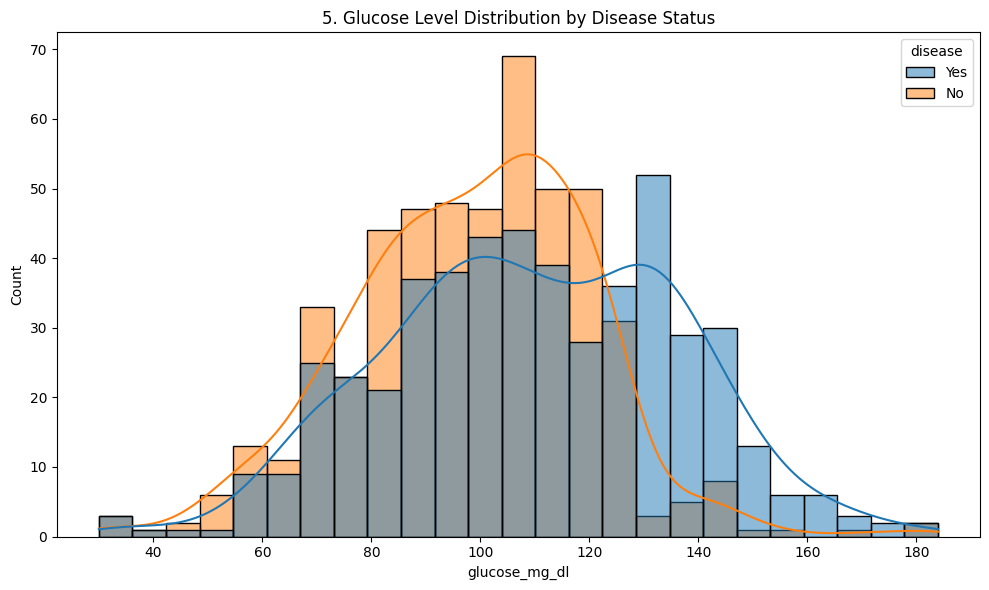

In [105]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='glucose_mg_dl', hue='disease', kde=True, bins=25)
plt.title(f'{plot_no}. Glucose Level Distribution by Disease Status')
show_fig()
if 'plot_no' not in globals():
    plot_no = 1

fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='glucose_mg_dl', hue='disease', kde=True, bins=25)
plt.title(f'{plot_no}. Glucose Level Distribution by Disease Status')
show_fig()
plot_no += 1

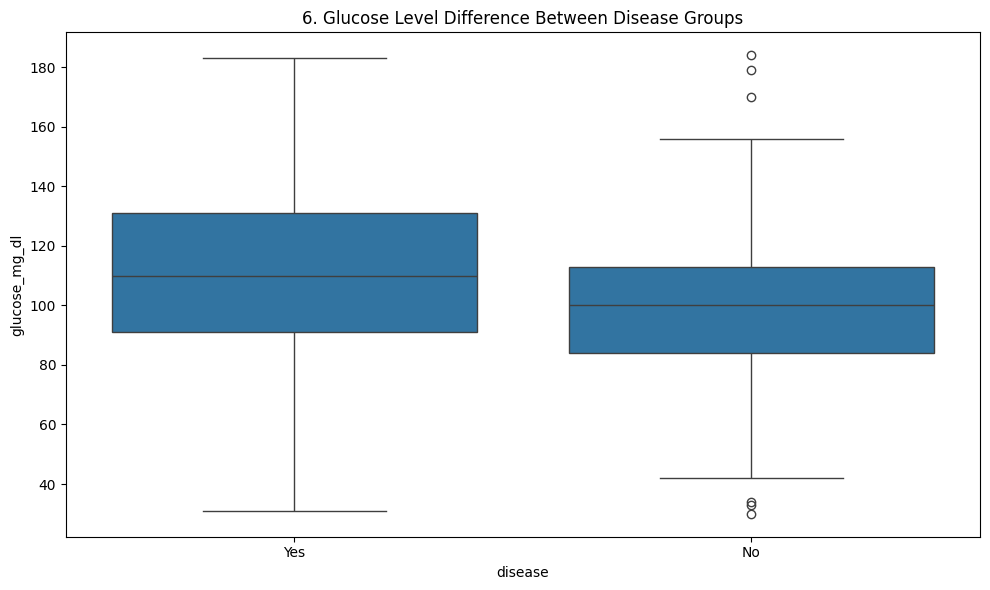

In [106]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='disease', y='glucose_mg_dl')
plt.title(f'{plot_no}. Glucose Level Difference Between Disease Groups')
show_fig()
plot_no += 1

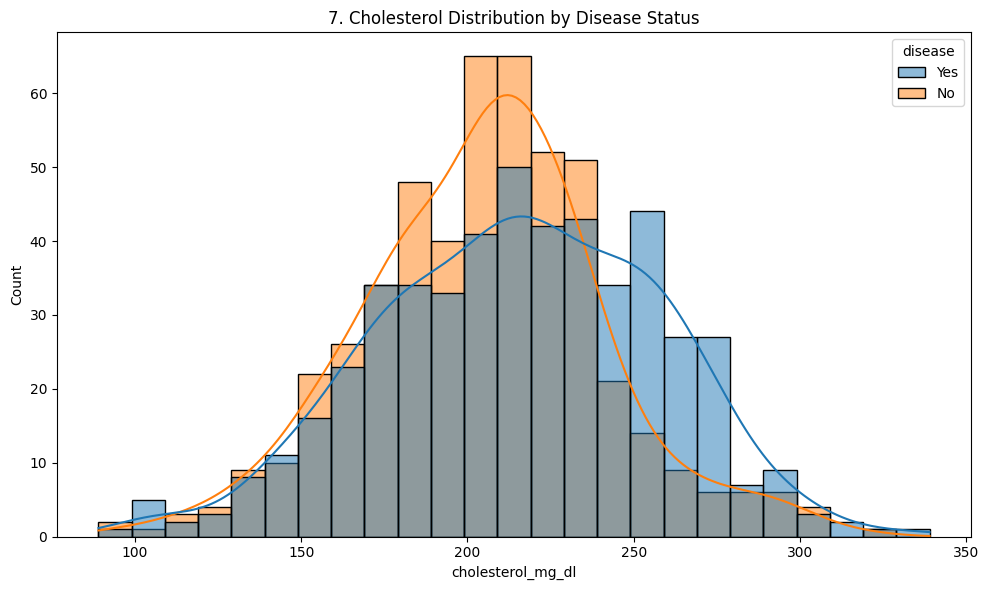

In [107]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='cholesterol_mg_dl', hue='disease', kde=True, bins=25)
plt.title(f'{plot_no}. Cholesterol Distribution by Disease Status')
show_fig()
plot_no += 1

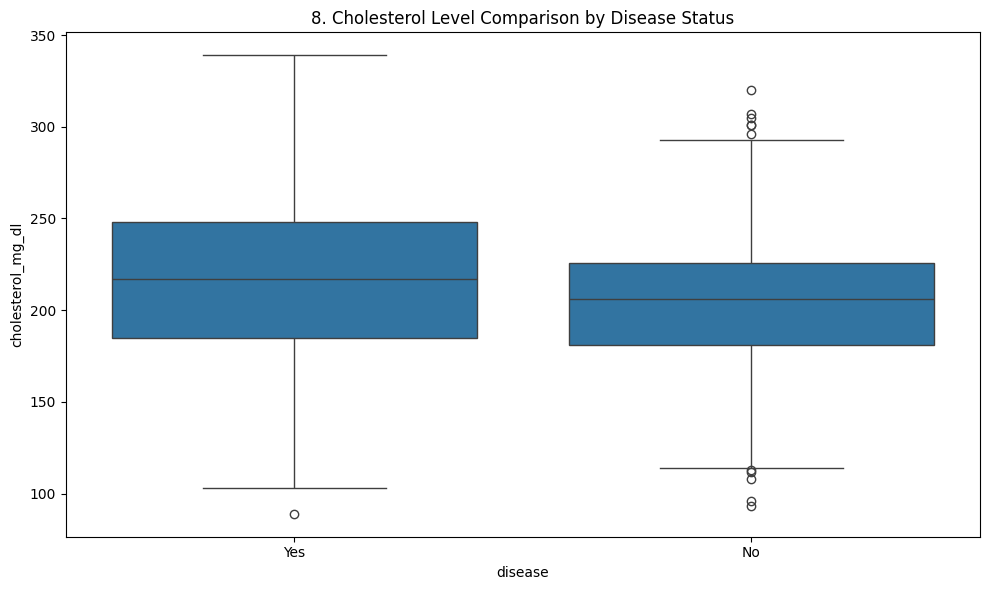

In [108]:
fig = plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='disease', y='cholesterol_mg_dl')
plt.title(f'{plot_no}. Cholesterol Level Comparison by Disease Status')
show_fig()
plot_no += 1

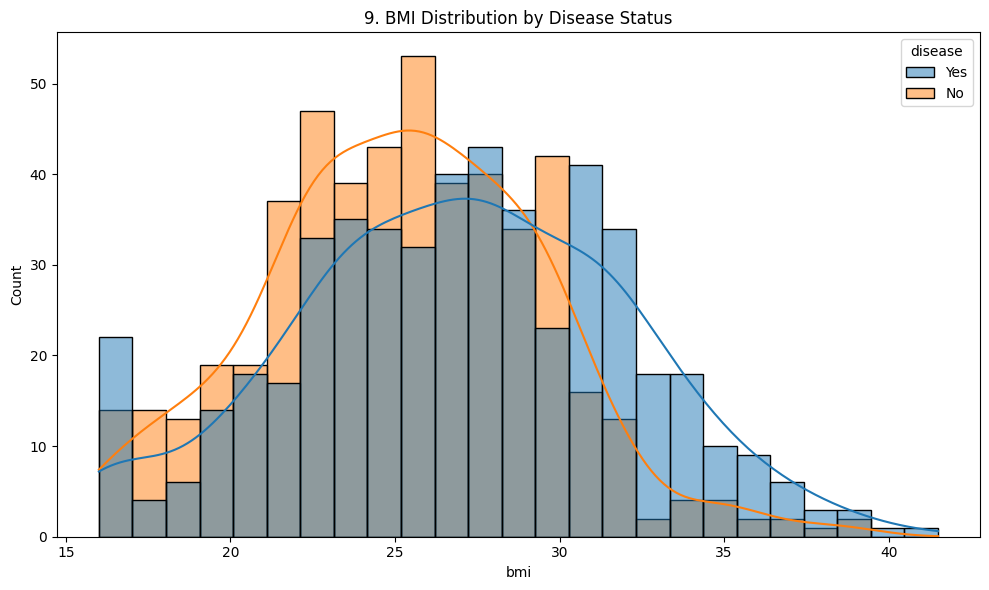

In [109]:
fig = plt.figure(figsize=(10,6))
sns.histplot(data=df, x='bmi', hue='disease', kde=True, bins=25)
plt.title(f'{plot_no}. BMI Distribution by Disease Status')
show_fig()
plot_no += 1

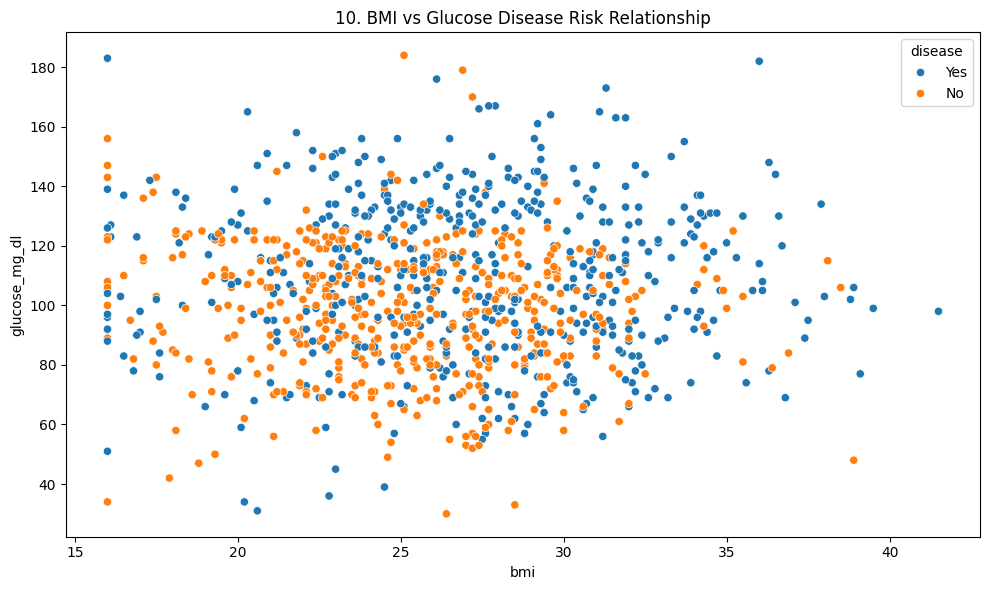

In [110]:
fig = plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='bmi', y='glucose_mg_dl', hue='disease')
plt.title(f'{plot_no}. BMI vs Glucose Disease Risk Relationship')
show_fig()
plot_no += 1

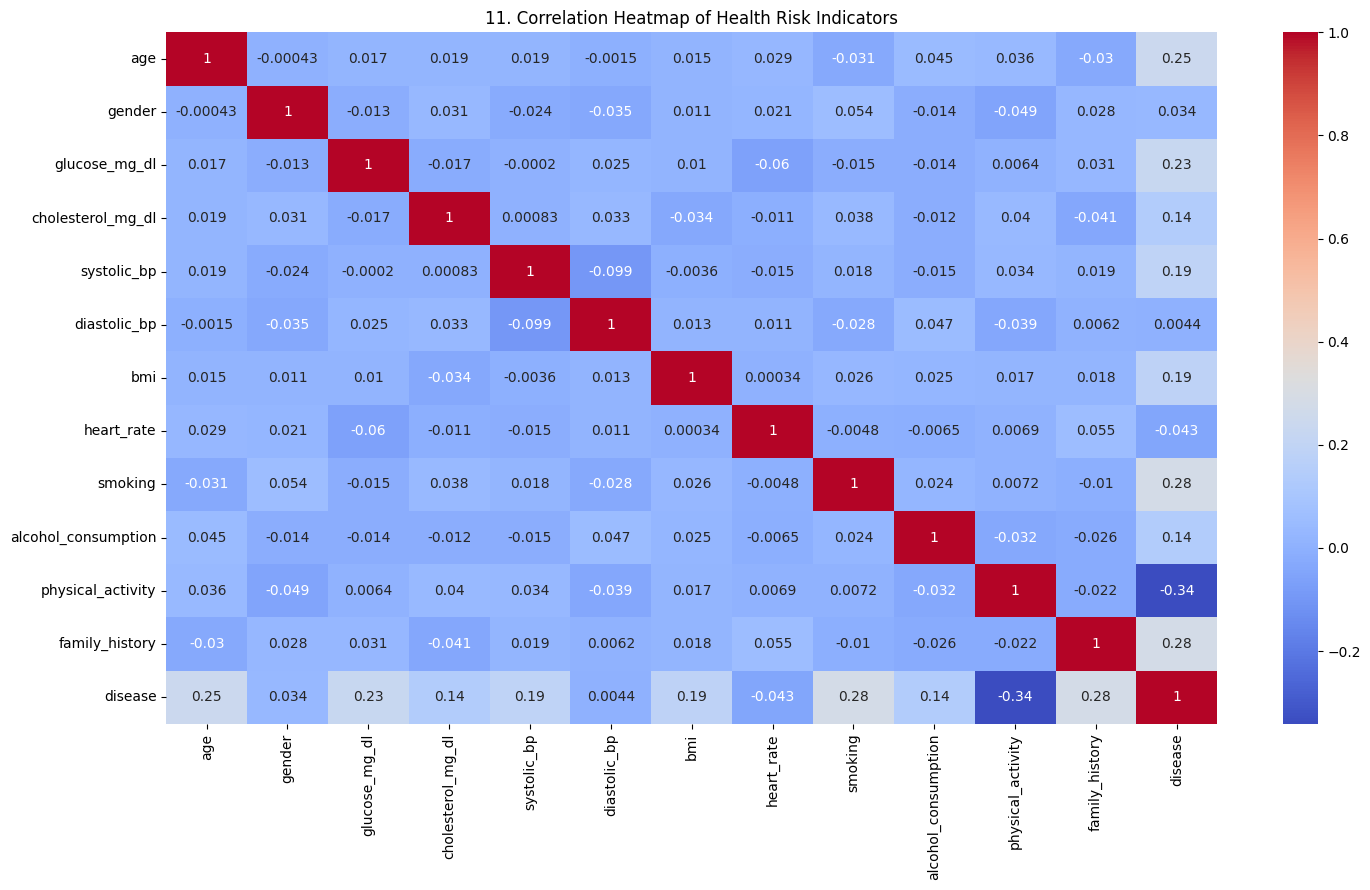

In [111]:
fig = plt.figure(figsize=(15, 9))
corr = df.copy()
corr['gender'] = corr['gender'].map({'Male': 1, 'Female': 0})
corr['smoking'] = corr['smoking'].map({'Yes': 1, 'No': 0})
corr['alcohol_consumption'] = corr['alcohol_consumption'].map({'Yes': 1, 'No': 0})
corr['physical_activity'] = corr['physical_activity'].map({'Low': 0, 'Medium': 1, 'High': 2})
corr['family_history'] = corr['family_history'].map({'Yes': 1, 'No': 0})
corr['disease'] = corr['disease'].map({'Yes': 1, 'No': 0})
corr = corr.drop(columns=['patient_id']).corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title(f'{plot_no}. Correlation Heatmap of Health Risk Indicators')
show_fig()
plot_no += 1

## Model Training
### Create copy of dataframe

In [112]:
data = df.copy()

### Select target column

In [113]:
target = 'disease'

### Separate input and output

In [114]:
X = data.drop(columns=[target])
y = data[target]

#### Find Categorical and numerical columns

In [115]:
cat_cols = X.select_dtypes(include=['object']).columns
num_cols = X.select_dtypes(exclude=['object']).columns

### Create preprocessing pipeline

In [116]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat',
         OrdinalEncoder(
             handle_unknown='use_encoded_value',
             unknown_value=-1
         ),
         cat_cols)
    ]
)

### Create Gradient Boosting model

In [117]:
model = GradientBoostingClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=3,
    subsample=0.9,
    random_state=42
)

### Create full training pipeline

In [118]:
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', model)
])

### Split data into train and test

In [119]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Train model

In [120]:
pipe.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['patient_id', 'age', 'glucose_mg_dl', 'cholesterol_mg_dl',
       'systolic_bp', 'diastolic_bp', 'bmi', 'heart_rate'],
      dtype='object')),
                                                 ('cat',
                                                  OrdinalEncoder(handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  Index(['gender', 'smoking', 'alcohol_consumption', 'physical_activity',
       'family_history'],
      dtype='object'))])),
                ('model',
                 GradientBoostingClassifier(learning_rate=0.05,
                                            n_estimators=300, random_state=42,
                                            subsample=0.9))])

### Predict test data

In [121]:
y_pred = pipe.predict(X_test)

### Print accuracy score

In [122]:
accuracy = accuracy_score(y_test, y_pred)
print('Model Accuracy: ', accuracy)

Model Accuracy:  0.955


### Print classification report


In [124]:
print("\nClassification Report: \n", classification_report(y_test, y_pred))


Classification Report: 
               precision    recall  f1-score   support

          No       0.95      0.96      0.96       100
         Yes       0.96      0.95      0.95       100

    accuracy                           0.95       200
   macro avg       0.96      0.95      0.95       200
weighted avg       0.96      0.95      0.95       200



### Create confusion matrix

In [125]:
cm = confusion_matrix(y_test, y_pred)

### Plot confusion matrix

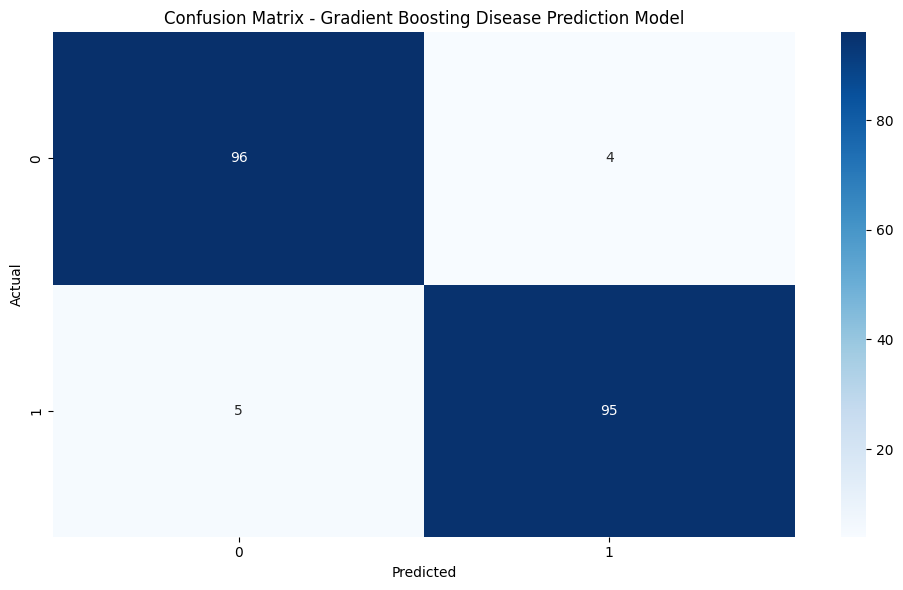

In [126]:
fig = plt.figure(figsize=(10,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Gradient Boosting Disease Prediction Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()